In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [2]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

# Retrieving and preparing the data

In [3]:
# Read data from URL

train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url,index_col=0)
val_df = pd.read_csv(val_url,index_col=0)
test_df = pd.read_csv(test_url,index_col=0)


print(f"""
Train samples: {train_df.shape[0]}
Validation samples: {val_df.shape[0]}
Test samples: {test_df.shape[0]}
""")


Train samples: 48991
Validation samples: 16331
Test samples: 21774



In [4]:
# Lets one hotn encode the target
y_train = pd.get_dummies(train_df['Genre']).to_numpy()
y_val = pd.get_dummies(val_df['Genre']).to_numpy()
y_test = pd.get_dummies(test_df['Genre']).to_numpy()

# Using pretrained embedding as-is
using popular word embeddings in Keras Embedding layer like Glove, Word2vec.

Here we will be using GloVe which is based on English wikipedia dataset.

GloVe contains 100 dimensional embedding vectors for 400,000 words.

In [5]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-10-09 09:38:43--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-10-09 09:38:44--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-10-09 09:38:44--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [6]:
!unzip -q glove.6B.zip

In [7]:
! head -1 /content/glove.6B.100d.txt

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062


In [8]:
embedding_dim = 100
path_to_glove_file = f"glove.6B.{embedding_dim}d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
  for line in f:
    word, coefs = line.split(maxsplit=1)
    coefs = np.fromstring(coefs, "f", sep=" ")
    embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Found 400000 word vectors.


In [9]:
embeddings_index["movie"]

array([ 0.38251  ,  0.14821  ,  0.60601  , -0.51533  ,  0.43992  ,
        0.061053 , -0.62716  , -0.025385 ,  0.1643   , -0.22101  ,
        0.14423  , -0.37213  , -0.21683  , -0.08895  ,  0.097904 ,
        0.6561   ,  0.64455  ,  0.47698  ,  0.83849  ,  1.6486   ,
        0.88922  , -0.1181   , -0.012465 , -0.52082  ,  0.77854  ,
        0.48723  , -0.014991 , -0.14127  , -0.34747  , -0.29595  ,
        0.1028   ,  0.57191  , -0.045594 ,  0.026443 ,  0.53816  ,
        0.32257  ,  0.40788  , -0.043599 , -0.146    , -0.48346  ,
        0.32036  ,  0.55086  , -0.76259  ,  0.43269  ,  0.61753  ,
       -0.36503  , -0.60599  , -0.79615  ,  0.3929   , -0.23668  ,
       -0.34719  , -0.61201  ,  0.54747  ,  0.94812  ,  0.20941  ,
       -2.7771   , -0.6022   ,  0.8495   ,  1.2549   ,  0.017893 ,
       -0.041901 ,  2.1147   , -0.026618 , -0.28104  ,  0.68124  ,
       -0.14165  ,  0.99249  ,  0.49879  , -0.67538  ,  0.6417   ,
        0.42303  , -0.27913  ,  0.063403 ,  0.68909  , -0.3618

Let's now load the GloVe embeddings into the model and train it!

First, we will set up the `TextVectorization` and `Embedding` layers.

In [10]:
max_length = 300 #90% of songs
max_tokens = 5000

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length, #output_sequence_length argument is used to either trunket or pad(with zeros) and make each sentense of some fixed length.
)

In [11]:
text_vectorization.adapt(train_df['Lyric'])

In [12]:
text_vectorization.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('you'),
 np.str_('i'),
 np.str_('to'),
 np.str_('and'),
 np.str_('a'),
 np.str_('me'),
 np.str_('it')]

When `output_mode = int`, the vocabulary will use index 0 for the empty string(' ') and 1 for `[UNK]`. We will sometimes refer to the empty string as `[PAD]`

In [13]:
text_vectorization(["HODL, you are the best!"])

<tf.Tensor: shape=(1, 300), dtype=int64, numpy=
array([[  1,   3,  58,   2, 258,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
   

In [14]:
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(val_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])

# `Embedding Layer`
Create matrix using GloVe embeddings. This is used for `Embedding` layer initialization.

In [15]:
vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

counter = 0
embedding_matrix = np.zeros((max_tokens, embedding_dim))
for word, i in word_index.items():
  if i < max_tokens:
    embedding_vector = embeddings_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector
  else:
    counter += 1

The above code creates a lookup table that maps integers to the corresponding word vectors

In [16]:
embedding_matrix.shape

(5000, 100)

In [17]:
embedding_matrix[:3,:]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [18]:
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,
    mask_zero=True
)

We have initialized the Embedding layer with the matrix we built earlier.

Like any other wights, weights from the embedding layer will also get updated in the gradient descent(i.e. backpropogation). But we want to use the weights from the GloVe as it is and thats why we added the parameter `trainable=False`.

In [19]:
inputs = keras.Input(shape=(max_length,))
embedded = embedding_layer(inputs) # 300 x 100 table comes out
embedded = keras.layers.GlobalAveragePooling1D()(embedded) # 100-element vector
x = keras.layers.Dense(8, activation='relu')(embedded) # only hidden layer
outputs = keras.layers.Dense(3, activation="softmax")(x) # output layer

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │    500,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │         27 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 835 (3.26 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [20]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

In [21]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.5487 - loss: 0.9270 - val_accuracy: 0.5556 - val_loss: 0.8888
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5824 - loss: 0.8617 - val_accuracy: 0.5870 - val_loss: 0.8445
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6043 - loss: 0.8304 - val_accuracy: 0.6047 - val_loss: 0.8219
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6194 - loss: 0.8093 - val_accuracy: 0.6220 - val_loss: 0.8001
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6284 - loss: 0.7950 - val_accuracy: 0.6303 - val_loss: 0.7899
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6329 - loss: 0.7871 - val_accuracy: 0.6334 - val_loss: 0.7829
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6360 - loss: 0.7823 - val_accuracy: 0.6371 - val_loss: 0.7798
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6388 - loss: 0.7780 

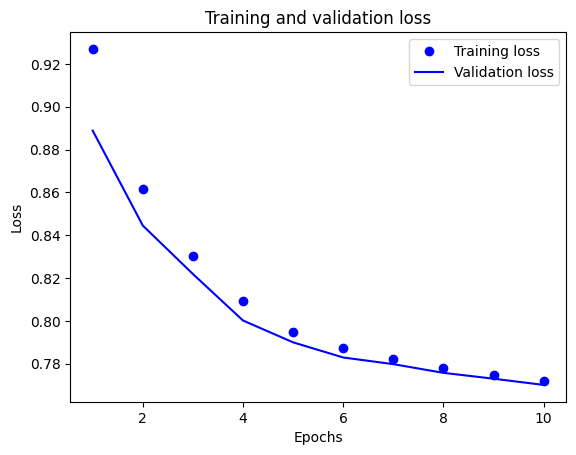

In [23]:
plot_loss_curves(history)

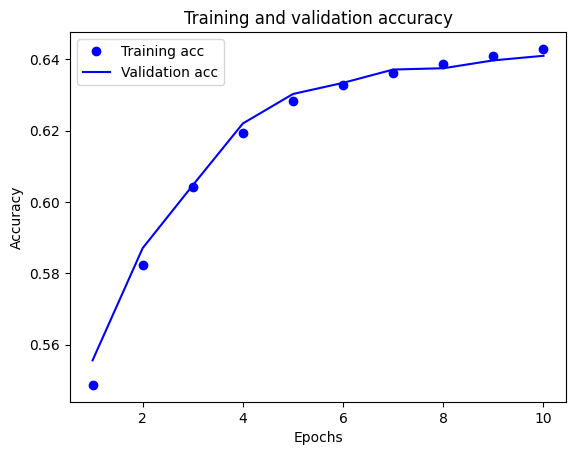

In [24]:
plot_acc_curves(history)

In [25]:
model.evaluate(X_test, y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6356 - loss: 0.7870


[0.7870206832885742, 0.6355745196342468]

In [26]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

In [27]:
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=True, # This has changed from before
    mask_zero=True
)
inputs = keras.Input(shape=(max_length,))
embedded = embedding_layer(inputs) # 300 x 100 table comes out
embedded = keras.layers.GlobalAveragePooling1D()(embedded) # 100-element vector
x = keras.layers.Dense(8, activation='relu')(embedded) # only hidden layer
outputs = keras.layers.Dense(3, activation="softmax")(x) # output layer

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 100)  │    500,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 300)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding_1[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         27 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 500,835 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_1/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6431 - loss: 0.7635 - val_accuracy: 0.7061 - val_loss: 0.6624
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7202 - loss: 0.6302 - val_accuracy: 0.7144 - val_loss: 0.6389
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7355 - loss: 0.5951 - val_accuracy: 0.7166 - val_loss: 0.6353
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7438 - loss: 0.5747 - val_accuracy: 0.7162 - val_loss: 0.6366
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7503 - loss: 0.5603 - val_accuracy: 0.7153 - val_loss: 0.6402
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7558 - loss: 0.5493 - val_accuracy: 0.7136 - val_loss: 0.6449
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7595 - loss: 0.5407 - val_accuracy: 0.7129 - val_loss: 0.6500
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7619 - loss: 0.5338 -

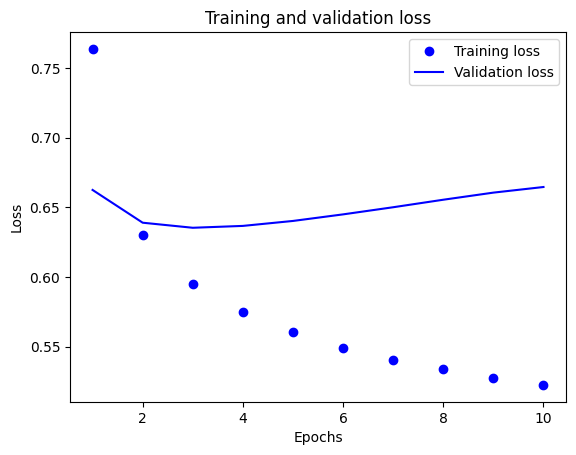

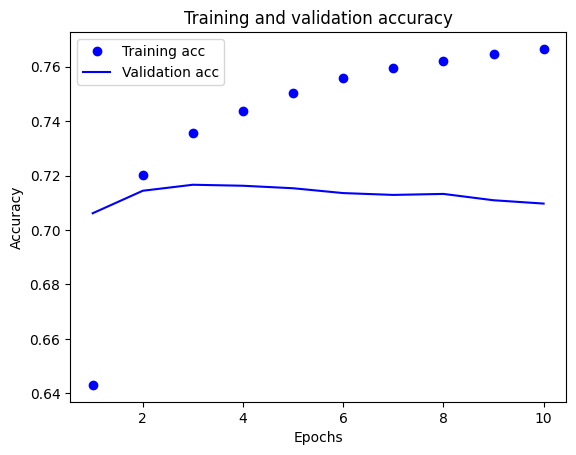

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7091 - loss: 0.6790


[0.6790331602096558, 0.7091485261917114]

In [29]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)
plot_loss_curves(history)
plot_acc_curves(history)
model.evaluate(X_test, y_test)

In [30]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_1/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.18979685  0.20436299  0.6614437  ...  0.2363384  -0.18010728
   -0.31241402]
  [-0.15049005 -0.3302088   0.49572766 ... -0.10710791  0.8508024
    0.07648523]
  ...
  [ 0.8828364  -0.55450094 -0.13499719 ...  0.03173131 -0.72250396
    1.1458039 ]
  [-0.74588567 -0.4065119  -0.4625337  ... -0.09379612 -0.95574355
   -0.6200446 ]
  [-0.7600415   0.18615317  0.39999413 ... -1.311954    0.4894054
    0.2711959 ]]>]

Training the GloVe embeddings with our data helps.

Lets confirm that the GloVe embeddings did get updated by backprop.

In [31]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_1/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.18979685  0.20436299  0.6614437  ...  0.2363384  -0.18010728
   -0.31241402]
  [-0.15049005 -0.3302088   0.49572766 ... -0.10710791  0.8508024
    0.07648523]
  ...
  [ 0.8828364  -0.55450094 -0.13499719 ...  0.03173131 -0.72250396
    1.1458039 ]
  [-0.74588567 -0.4065119  -0.4625337  ... -0.09379612 -0.95574355
   -0.6200446 ]
  [-0.7600415   0.18615317  0.39999413 ... -1.311954    0.4894054
    0.2711959 ]]>]

`[PAD]` weights does not gets updated cause they are just their to make matrix multipleication easier. Thats why they are untouched by backprop by design.

# Learnign embedding from scratch

In [35]:
inputs = keras.Input(shape=(max_length,))

embedded = keras.layers.Embedding(input_dim=max_tokens,
                                  output_dim=64,
                                  mask_zero=True)(inputs)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)

x = keras.layers.Dense(16, activation='relu')(embedded)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 300, 64)   │    320,000 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 300)       │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ embedding_4[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      1,040 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │         51 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,091 (1.22 MB)

 Trainable params: 321,091 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_4/embeddings, shape=(5000, 64), dtype=float32, value=[[ 0.00822203 -0.01623904  0.02718992 ... -0.01419135 -0.0232712
   -0.03445933]
  [-0.03070483 -0.00807657  0.00345129 ... -0.04035274  0.01570851
   -0.01046403]
  [-0.00322319 -0.03660885 -0.03013239 ...  0.02504062 -0.04973106
    0.01718641]
  ...
  [ 0.0263578   0.03838888 -0.02996435 ... -0.01260672 -0.02379847
    0.01418156]
  [ 0.04270215  0.01441319 -0.039488   ... -0.03771802 -0.02434479
   -0.0395027 ]
  [-0.04080839  0.03682581  0.01915051 ...  0.04836718 -0.01598345
    0.0031196 ]]>]

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6390 - loss: 0.7795 - val_accuracy: 0.7045 - val_loss: 0.6570
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6988 - loss: 0.6720 - val_accuracy: 0.7132 - val_loss: 0.6375
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7146 - loss: 0.6383 - val_accuracy: 0.7136 - val_loss: 0.6336
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7260 - loss: 0.6178 - val_accuracy: 0.7093 - val_loss: 0.6388
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7309 - loss: 0.6027 - val_accuracy: 0.7093 - val_loss: 0.6465
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7367 - loss: 0.5874 - val_accuracy: 0.7120 - val_loss: 0.6469
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7380 - loss: 0.5778 - val_accuracy: 0.7101 - val_loss: 0.6561
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7456 - loss: 0.5665 -

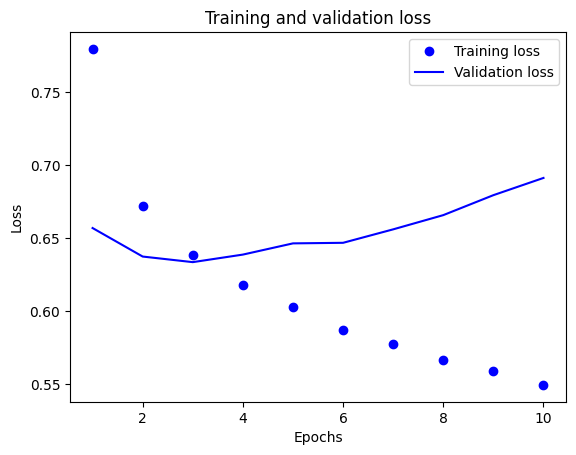

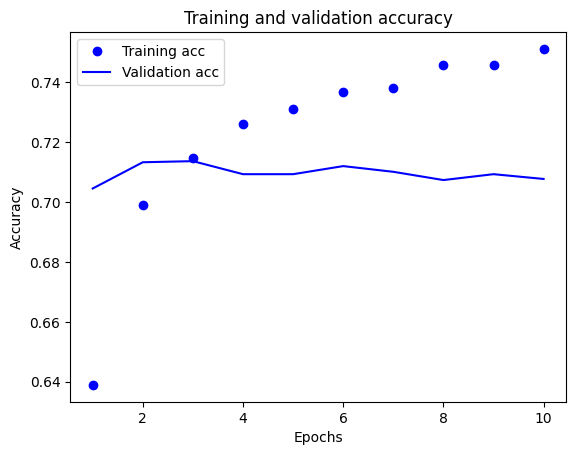

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7065 - loss: 0.7113


[0.7112622857093811, 0.706530749797821]

In [37]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)
plot_loss_curves(history)
plot_acc_curves(history)
model.evaluate(X_test, y_test)

In [38]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_4/embeddings, shape=(5000, 64), dtype=float32, value=[[ 0.00822203 -0.01623904  0.02718992 ... -0.01419135 -0.0232712
   -0.03445933]
  [-0.08037213  0.05839125 -0.05742713 ...  0.07415383 -0.0522802
   -0.11375131]
  [-0.01614666 -0.0191003  -0.07175508 ...  0.09929659 -0.17076655
   -0.05210801]
  ...
  [-0.10831776 -0.25473702  0.04490134 ... -0.01053352 -0.4237137
    0.3165973 ]
  [ 0.8344738   0.7979328   0.50781083 ... -0.6064718   0.03285789
   -0.78150594]
  [-0.12390705  1.1314274   0.12777387 ...  0.31634808  0.10483894
   -0.5248017 ]]>]

Here you can see that except `[PAD]` vector, every other vector is changed. This happened because of `mask_zero=TRUE` flag.

Pretrained embeddings ncan be helpful when you have comparitively less data available at hand.